In [35]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [36]:
import torch
import torch.optim as optim
import numpy as np
from model import NP_model
from dataset import get_image_dataloader, ImageDataset
from train import train
import matplotlib.pyplot as plt

In [37]:
config = {
    'dataset': 'mnist',           # 'mnist' or 'cifar10'
    'max_context_points': 261,  # For MNIST (28x28=784), 392  is 50% of pixels, 261 is 33%
    'batch_size': 4,
    'num_workers': 4,
    'input_dim_x': 2,             # 2D coordinates (x, y)
    'input_dim_y': 1,             # Grayscale (1 for MNIST, 3 for CIFAR10)
    'hidden_dim': 128*3,
    'output_dim': 1,              # Prediction dimension (1 for MNIST, 3 for CIFAR10)
    'learning_rate': 5e-4,
    'num_epochs': 50,
    'save_every': 10,
    'seed': 41,
}


In [38]:

# Set random seed for reproducibility
torch.manual_seed(config['seed'])
np.random.seed(config['seed'])

# Device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# Create dataloaders
print("Loading datasets...")
train_loader = get_image_dataloader(
    dataset_name=config['dataset'],
    batch_size=config['batch_size'],
    num_workers=config['num_workers'],
    max_context_points=config['max_context_points'],
    train=True,
    flatten=True
)

val_loader = get_image_dataloader(
    dataset_name=config['dataset'],
    batch_size=config['batch_size'],
    num_workers=config['num_workers'],
    max_context_points=config['max_context_points'],
    train=False,
    flatten=True
)

Loading datasets...
Image dimensions (H, W, C): (28, 28, 1)
Using max_context_points: 261
Image dimensions (H, W, C): (28, 28, 1)
Using max_context_points: 261


In [39]:
# Create model
print("\nCreating model...")
model = NP_model(
    input_dim_x=config['input_dim_x'],
    input_dim_y=config['input_dim_y'],
    hidden_dim=config['hidden_dim'],
    output_dim=config['output_dim']
)
model = model.to(device)

# Count parameters
num_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Model has {num_params:,} trainable parameters")

# Create optimizer
optimizer = optim.Adam(model.parameters(), lr=config['learning_rate'])


Creating model...
Model has 452,018 trainable parameters


In [ ]:
import time
timestamp = time.strftime("%d_%b_%Y_%H:%M:%S", time.localtime())

model_name = "NP_model_{timestamp}.pt"

# Train
print("\n" + "=" * 60)
train_losses, val_losses = train(
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    optimizer=optimizer,
    device=device,
    num_epochs=config['num_epochs'],
    save_dir='checkpoints',
    save_every=config['save_every'],
    model_name=model_name
)

# Save training history
np.save('checkpoints/train_losses.npy', train_losses)
np.save('checkpoints/val_losses.npy', val_losses)
print("\nTraining history saved to checkpoints/")


Starting training for 50 epochs...
Device: cuda
Training batches: 15000, Validation batches: 2500
------------------------------------------------------------


Epoch   1/50 | Train Loss: -1.586437 | Val Loss: -1.539276
  → Saved best model (val_loss: -1.539276)


Epoch   2/50 | Train Loss: -1.697239 | Val Loss: -1.752601
  → Saved best model (val_loss: -1.752601)


Epoch   3/50 | Train Loss: -1.775245 | Val Loss: -1.799919
  → Saved best model (val_loss: -1.799919)


Epoch   4/50 | Train Loss: -1.833009 | Val Loss: -1.861286
  → Saved best model (val_loss: -1.861286)


...

Epoch  16/50 | Train Loss: -1.994479 | Val Loss: -2.019245
  → Saved best model (val_loss: -2.019245)


Epoch  17/50 | Train Loss: -1.997687 | Val Loss: -1.983808


Epoch  18/50 | Train Loss: -2.005526 | Val Loss: -2.011721


Epoch  19/50 | Train Loss: -2.006632 | Val Loss: -2.015095


Training:  46%|████▌     | 6923/15000 [00:28<00:31, 256.98it/s]

In [8]:
from utils import load_model_from_checkpoint
best_model, checkpoint_info = load_model_from_checkpoint('checkpoints/best_model.pt', config['input_dim_x'], config['input_dim_y'], config['hidden_dim'], config['output_dim'], device='cuda')

Loaded model from checkpoints/best_model.pt
  Epoch: 43
  Train Loss: -2.054250
  Val Loss: -2.080468


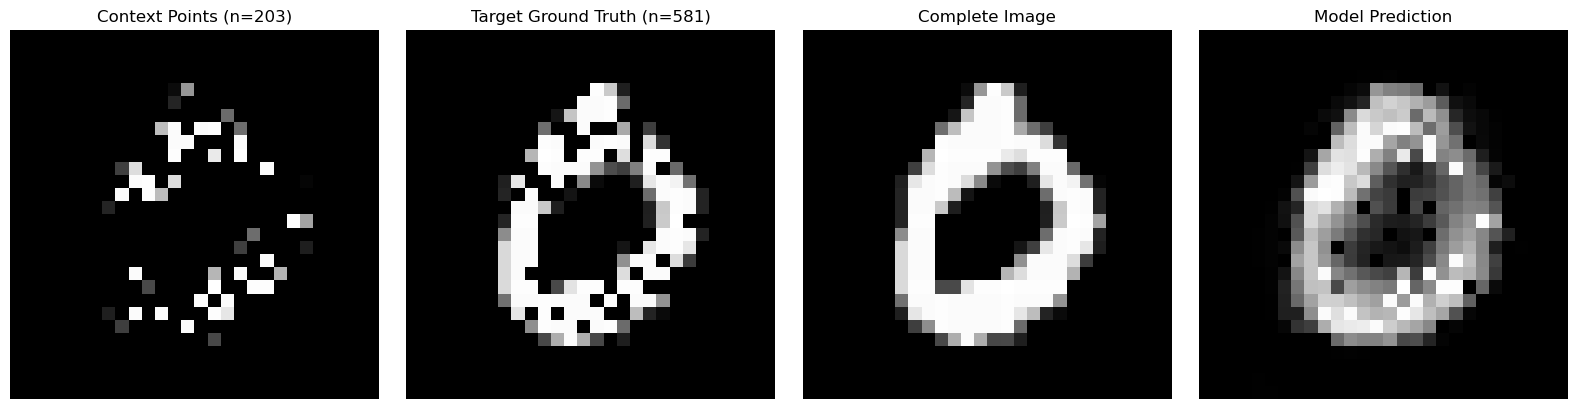

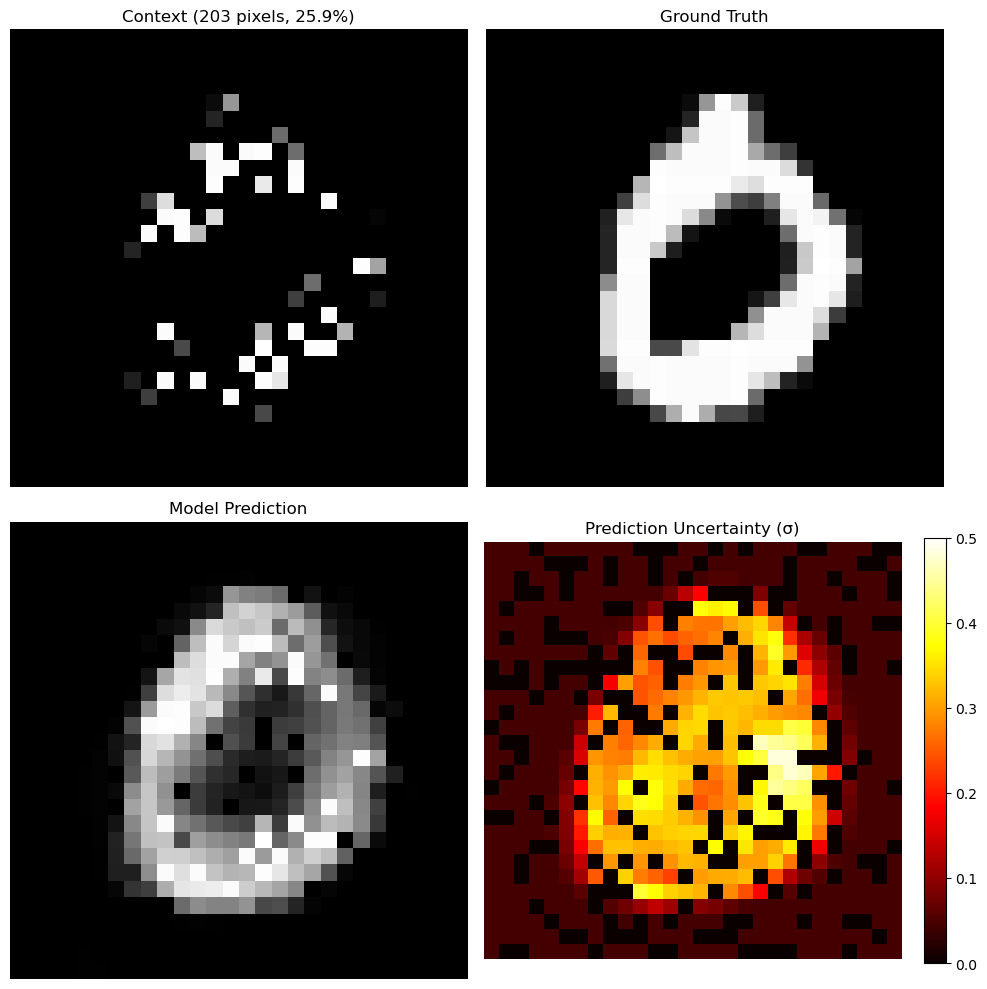

In [34]:
from utils import plot_mnist_sample, plot_prediction_comparison, plot_training_curves
from dataset import get_image_dataloader

# Get a batch
batch = next(iter(val_loader))


# With model predictions
fig = plot_mnist_sample(batch, batch_idx=3, model=best_model, device='cuda')
plt.show()

# Detailed comparison with uncertainty
fig = plot_prediction_comparison(batch, batch_idx=3, model=best_model, device='cuda')
plt.show()